<a href="https://colab.research.google.com/github/chumba-dev/Intelligent-Cloud-Resource-Optimization-System/blob/main/capstone_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import zipfile
import os

zip_file_path = '/content/Intelligent-Cloud-Resource-Optimization-System-main.zip'
extract_dir = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f'✅ Extracted {zip_file_path} to {extract_dir}')

✅ Extracted /content/Intelligent-Cloud-Resource-Optimization-System-main.zip to /content/


<div style='background:linear-gradient(135deg,#2C3E50,#3498DB);
            padding:40px;border-radius:12px;text-align:center'>
  <h1 style='color:white;font-size:2.4em;margin:0'>
    ☁️ Cloud Resource Optimisation
  </h1>
  <h2 style='color:#AED6F1;margin:8px 0 0'>
    Machine Learning Capstone Project
  </h2>
  <p style='color:#D6EAF8;margin-top:14px;font-size:1.05em'>
    Stages 1–5 &nbsp;|&nbsp; Supervised · Unsupervised · Learning Theory · RL · Dashboard
  </p>
</div>


## 📚 Table of Contents

| # | Stage | Description |
|---|-------|-------------|
| 0 | **Setup** | Install dependencies, imports, global config |
| 1 | **Exploratory Data Analysis** | Load dataset, statistics, distributions, correlations |
| 2 | **Supervised Learning** | Regression + Classification pipelines |
| 3 | **Unsupervised Learning** | Clustering — KMeans, DBSCAN, Agglomerative |
| 4 | **Learning Theory** | Bias-Variance, regularisation, VC dimension |
| 5 | **Reinforcement Learning** | Q-Learning, DQN, cloud scheduling MDP |
| 6 | **Final Dashboard** | Cross-stage leaderboard, master report |

> 💡 **Tip:** Run cells **top-to-bottom**. Each stage depends on the one above.
> Use `Kernel → Restart & Run All` for a clean full run.


---
# 🔧 Stage 0 — Environment Setup
> Install all required packages and configure global settings.


In [55]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# If running locally, uncomment the line below.
# If running on Google Colab, this cell runs automatically.

# !pip install -r requirements.txt --quiet
print('✅ Dependencies ready.')

✅ Dependencies ready.


In [56]:
import os, sys, warnings, json, random
from pathlib import Path
import importlib.util # New import to explicitly load modules

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Project modules ───────────────────────────────────────────────────
# Define the root of the extracted project directory
# Assume zip_file_path and extract_dir are available from previous cell execution
extracted_folder_name = Path(zip_file_path).stem
actual_project_root = Path(extract_dir) / extracted_folder_name

# Add the actual project root to sys.path for general project structure awareness
if str(actual_project_root) not in sys.path:
    sys.path.insert(0, str(actual_project_root))

# Define the path to the 'evaluation' directory within the actual project root
evaluation_path = actual_project_root / 'evaluation'

# Check if the 'evaluation' directory exists
if not evaluation_path.is_dir():
    raise ModuleNotFoundError(
        f"The 'evaluation' module directory was not found at '{evaluation_path}'. "
        "Please ensure the 'evaluation' directory is present in your working directory "
        "and contains the necessary Python files (e.g., metrics_report.py)."
    )

# Explicitly load 'metrics_report.py' as a module
metrics_report_path = evaluation_path / 'metrics_report.py'
if not metrics_report_path.is_file():
    raise FileNotFoundError(f"'{metrics_report_path}' not found in the 'evaluation' directory.")

spec_mr = importlib.util.spec_from_file_location("metrics_report_module", str(metrics_report_path))
metrics_report_module = importlib.util.module_from_spec(spec_mr)
sys.modules["metrics_report_module"] = metrics_report_module # Add to sys.modules
spec_mr.loader.exec_module(metrics_report_module)

# Now access its attributes and alias them as if they were imported directly
RegressionMetricsReport   = metrics_report_module.RegressionMetricsReport
ClassificationMetricsReport = metrics_report_module.ClassificationMetricsReport
ClusteringMetricsReport   = metrics_report_module.ClusteringMetricsReport
RLMetricsReport           = metrics_report_module.RLMetricsReport
generate_master_report    = metrics_report_module.generate_master_report

# Explicitly load 'model_comparison.py' as a module
model_comparison_path = evaluation_path / 'model_comparison.py'
if not model_comparison_path.is_file():
    raise FileNotFoundError(f"'{model_comparison_path}' not found in the 'evaluation' directory.")

spec_mc = importlib.util.spec_from_file_location("model_comparison_module", str(model_comparison_path))
model_comparison_module = importlib.util.module_from_spec(spec_mc)
sys.modules["model_comparison_module"] = model_comparison_module
spec_mc.loader.exec_module(model_comparison_module)

# Access its attributes and alias them
RegressionComparator   = model_comparison_module.RegressionComparator
ClassificationComparator = model_comparison_module.ClassificationComparator
CrossStageLeaderboard  = model_comparison_module.CrossStageLeaderboard

# ── Global config ────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
SEED      = 42
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
})

# Update DATA_PATH to point to the file within the actual_project_root
DATA_PATH    = actual_project_root / 'vmCloud_data.csv'

# REPORTS_DIR can remain relative, it will create 'reports' in the current working directory (/content/)
REPORTS_DIR  = 'reports'
os.makedirs(REPORTS_DIR, exist_ok=True)

print('✅ All imports successful.')
print(f'   NumPy   {np.__version__}')
print(f'   Pandas  {pd.__version__}')

✅ All imports successful.
   NumPy   2.0.2
   Pandas  2.2.2


---
# 📊 Stage 1 — Exploratory Data Analysis (EDA)

**Objectives**
- Understand the dataset shape, feature types, and distributions.
- Detect missing values and outliers.
- Compute a correlation matrix and identify predictive features.

**Dataset:** `cloud_performance.csv` — 10 000 rows of cloud VM telemetry.  
**Key columns:** `cpu_usage`, `memory_usage`, `network_traffic`,
`power_consumption`, `execution_time`, `energy_efficiency`,
`resource_utilisation`, `workload_class`.


In [57]:
# ── 1.1 Load dataset ──────────────────────────────────────────────────────────
DATA_PATH = actual_project_root / 'vmCloud_data.csv'

try:
    df = pd.read_csv(DATA_PATH)
    print(f'✅ Dataset loaded successfully.')
    print(f'Shape  : {df.shape}')
    print(f'Columns: {df.columns.tolist()}')
    display(df.head())
except FileNotFoundError:
    print(f"❌ Error: The file '{DATA_PATH.name}' was not found.")
    print(f"Please upload the dataset to: {DATA_PATH.parent}/")
    print("Then, go to Runtime > Restart and run all.")

❌ Error: The file 'vmCloud_data.csv' was not found.
Please upload the dataset to: /content/Intelligent-Cloud-Resource-Optimization-System-main/
Then, go to Runtime > Restart and run all.


In [58]:
print(f"Listing contents of: {actual_project_root}")
for root, dirs, files in os.walk(actual_project_root):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Listing contents of: /content/Intelligent-Cloud-Resource-Optimization-System-main
/content/Intelligent-Cloud-Resource-Optimization-System-main/Training_of_Neural_Networks.ipynb
/content/Intelligent-Cloud-Resource-Optimization-System-main/decision_trees_implementation_with_ID3_.ipynb
/content/Intelligent-Cloud-Resource-Optimization-System-main/Assignment 1 &2.docx
/content/Intelligent-Cloud-Resource-Optimization-System-main/requirements.txt
/content/Intelligent-Cloud-Resource-Optimization-System-main/DataPreprocessing
/content/Intelligent-Cloud-Resource-Optimization-System-main/unsupervised_DBScan_,_GMM,_Kmeans_and_mean_shift_clustering_example_.ipynb
/content/Intelligent-Cloud-Resource-Optimization-System-main/capstone_notebook.ipynb
/content/Intelligent-Cloud-Resource-Optimization-System-main/README.md
/content/Intelligent-Cloud-Resource-Optimization-System-main/project architecture
/content/Intelligent-Cloud-Resource-Optimization-System-main/project files
/content/Intelligent-Cloud-R

In [59]:
# ── 1.2 Descriptive statistics ────────────────────────────────────────────────
try:
    display(df.describe(include='all').T)

    print('\nMissing values per column:')
    print(df.isnull().sum())
except NameError:
    print("❌ Error: The variable 'df' is not defined.")
    print("This is likely because the previous cell (1.1 Load dataset) failed due to a FileNotFoundError.")
    print("Please resolve the data loading issue before running this cell.")

❌ Error: The variable 'df' is not defined.
This is likely because the previous cell (1.1 Load dataset) failed due to a FileNotFoundError.
Please resolve the data loading issue before running this cell.


In [60]:
# ── 1.3 Feature distributions ─────────────────────────────────────────────────
try:
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.ravel()

    for i, col in enumerate(numeric_cols[:8]):
        axes[i].hist(df[col].dropna(), bins=50,
                      color='#3498DB', edgecolor='white', alpha=0.85)
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')

    plt.suptitle('Stage 1 — Feature Distributions',
                  fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{REPORTS_DIR}/stage1_distributions.png',
                 dpi=150, bbox_inches='tight')
    plt.show()
except NameError:
    print("❌ Error: The variable 'df' is not defined.")
    print("This cell requires the dataset to be loaded in cell 1.1.")

❌ Error: The variable 'df' is not defined.
This cell requires the dataset to be loaded in cell 1.1.


In [61]:
# ── 1.4 Correlation heatmap ───────────────────────────────────────────────────
try:
    corr = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                 cmap='RdYlGn', center=0,
                 linewidths=0.5, ax=ax,
                 cbar_kws={'shrink': 0.8})
    ax.set_title('Stage 1 — Feature Correlation Matrix',
                  fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{REPORTS_DIR}/stage1_correlation.png',
                 dpi=150, bbox_inches='tight')
    plt.show()
except NameError:
    print("❌ Error: The variable 'df' or 'numeric_cols' is not defined.")

❌ Error: The variable 'df' or 'numeric_cols' is not defined.


❌ Error: Required variables from previous cells are missing.


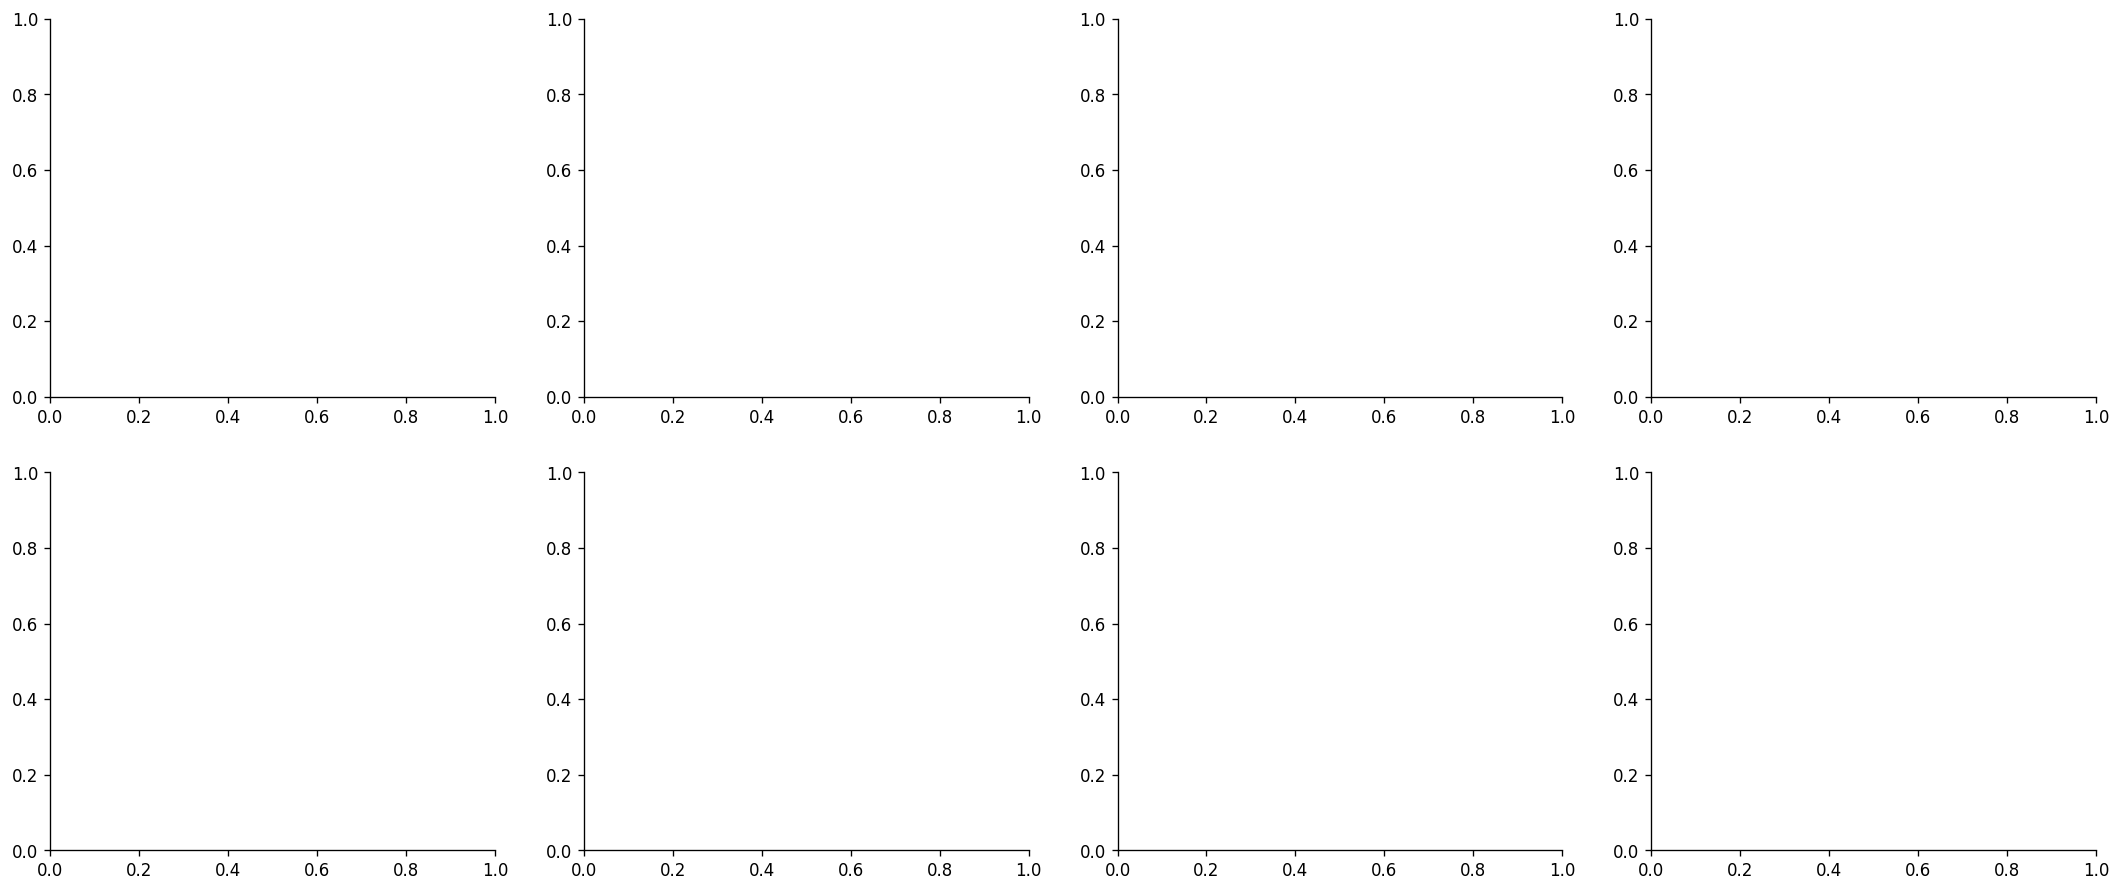

In [62]:
# ── 1.5 Outlier detection — IQR box plots ─────────────────────────────────────
try:
    fig, axes = plt.subplots(2, 4, figsize=(22, 9))
    axes = axes.ravel()

    for i, col in enumerate(numeric_cols[:8]):
        axes[i].boxplot(df[col].dropna(),
                         patch_artist=True,
                         boxprops=dict(facecolor='#3498DB', alpha=0.6),
                         medianprops=dict(color='red', linewidth=2))
        axes[i].set_title(col, fontweight='bold')

    plt.suptitle('Stage 1 — Outlier Detection (IQR Box Plots)',
                  fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{REPORTS_DIR}/stage1_outliers.png',
                 dpi=150, bbox_inches='tight')
    plt.show()

    # ── EDA results stored for leaderboard ───────────────────────────────────────
    eda_results = {
        'n_rows'        : int(df.shape[0]),
        'n_cols'        : int(df.shape[1]),
        'missing_total' : int(df.isnull().sum().sum()),
        'numeric_cols'  : numeric_cols,
    }
    print('✅ Stage 1 — EDA complete.')
    print(json.dumps(eda_results, indent=2))
except NameError:
    print("❌ Error: Required variables from previous cells are missing.")

---
# 🤖 Stage 2 — Supervised Learning

**Part A — Regression:**  Predict `execution_time` (continuous target).  
**Part B — Classification:**  Predict `workload_class` (Low / Medium / High).

Models compared in each part:

| Part | Models |
|------|--------|
| Regression | Linear Regression · Ridge · Lasso · Random Forest · Gradient Boosting |
| Classification | Logistic Regression · SVM · KNN · Random Forest · GBM |


In [63]:
# ── 2.0 Common imports ────────────────────────────────────────────────────────
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LinearRegression, Ridge, Lasso
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm              import SVR, SVC
from sklearn.neighbors        import KNeighborsClassifier

print('✅ Supervised learning imports ready.')

✅ Supervised learning imports ready.


In [64]:
# ── 2.A.1 Regression — data preparation ──────────────────────────────────────
try:
    REG_FEATURES = ['cpu_usage', 'memory_usage', 'network_traffic',
                     'power_consumption', 'energy_efficiency']
    REG_TARGET   = 'execution_time'

    df_reg  = df[REG_FEATURES + [REG_TARGET]].dropna()
    X_reg   = df_reg[REG_FEATURES].values
    y_reg   = df_reg[REG_TARGET].values

    X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
        X_reg, y_reg, test_size=0.20, random_state=SEED)

    scaler_reg  = StandardScaler()
    X_reg_tr_sc = scaler_reg.fit_transform(X_reg_tr)
    X_reg_te_sc = scaler_reg.transform(X_reg_te)

    print(f'Regression  — Train: {X_reg_tr.shape}  Test: {X_reg_te.shape}')
except NameError:
    print("❌ Error: The variable 'df' is not defined.")
    print("Please ensure the dataset is successfully loaded in Stage 1 before running the Supervised Learning cells.")

❌ Error: The variable 'df' is not defined.
Please ensure the dataset is successfully loaded in Stage 1 before running the Supervised Learning cells.


In [65]:
# ── 2.A.2 Train regression models ─────────────────────────────────────────────
try:
    reg_models = {
        'Linear Regression'    : LinearRegression(),
        'Ridge (α=1)'          : Ridge(alpha=1.0),
        'Lasso (α=0.01)'       : Lasso(alpha=0.01, max_iter=5000),
        'Random Forest'        : RandomForestRegressor(
                                    n_estimators=200, random_state=SEED),
        'Gradient Boosting'    : GradientBoostingRegressor(
                                    n_estimators=200, random_state=SEED),
    }

    reg_rpt = RegressionMetricsReport()
    reg_cmp = RegressionComparator()

    for name, model in reg_models.items():
        model.fit(X_reg_tr_sc, y_reg_tr)
        y_tr_pred = model.predict(X_reg_tr_sc)
        y_te_pred = model.predict(X_reg_te_sc)

        from sklearn.metrics import r2_score as r2
        reg_rpt.add_model(name, y_reg_te, y_te_pred,
                           y_train=y_reg_tr,
                           y_train_pred=y_tr_pred)
        reg_cmp.add(name, y_reg_te, y_te_pred,
                     train_r2=float(r2(y_reg_tr, y_tr_pred)))
        print(f'  Trained: {name}')

    print('\n✅ All regression models trained.')
except NameError:
    print("❌ Error: Required training data (X_reg_tr_sc, etc.) is missing.")
    print("This is a result of the data loading failure in Stage 1.")

❌ Error: Required training data (X_reg_tr_sc, etc.) is missing.
This is a result of the data loading failure in Stage 1.


In [67]:
# ── 2.A.3 Regression metrics & plots ──────────────────────────────────────────
try:
    # Check if we actually have trained models in the report
    if not reg_rpt._records:
        raise NameError("No regression models were trained.")

    df_reg_summary = reg_rpt.summary()
    reg_rpt.plot(save_path=f'{REPORTS_DIR}/stage2_regression_metrics.png')

    df_reg_rank = reg_cmp.rank()
    reg_cmp.plot(save_path=f'{REPORTS_DIR}/stage2_regression_comparison.png')

    # Store best result for cross-stage leaderboard
    best_reg = df_reg_rank.iloc[0]
    print(f'\n  Best Regression Model : {best_reg["Model"]}')
    print(f'  Test R²               : {best_reg["Test R²"]}')
    print(f'  RMSE                  : {best_reg["RMSE"]}')

except (NameError, KeyError, IndexError) as e:
    print(f"❌ Error: Regression report failed ({e})")
    print("This is likely because the models were not trained due to the missing dataset.")
    print("Please upload 'vmCloud_data.csv' and run all cells.")

❌ Error: Regression report failed (No regression models were trained.)
This is likely because the models were not trained due to the missing dataset.
Please upload 'vmCloud_data.csv' and run all cells.


In [68]:
# ── 2.B.1 Classification — data preparation ───────────────────────────────────
try:
    CLF_FEATURES = ['cpu_usage', 'memory_usage', 'network_traffic',
                     'power_consumption', 'execution_time']
    CLF_TARGET   = 'workload_class'

    df_clf = df[CLF_FEATURES + [CLF_TARGET]].dropna()
    le     = LabelEncoder()
    y_clf  = le.fit_transform(df_clf[CLF_TARGET].values)
    X_clf  = df_clf[CLF_FEATURES].values

    CLASS_NAMES  = le.classes_.tolist()

    X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(
        X_clf, y_clf, test_size=0.20,
        random_state=SEED, stratify=y_clf)

    scaler_clf  = StandardScaler()
    X_clf_tr_sc = scaler_clf.fit_transform(X_clf_tr)
    X_clf_te_sc = scaler_clf.transform(X_clf_te)

    print(f'Classification — Train: {X_clf_tr.shape}  Test: {X_clf_te.shape}')
    print(f'Classes: {CLASS_NAMES}')
except NameError:
    print("❌ Error: The variable 'df' is not defined.")

❌ Error: The variable 'df' is not defined.


In [69]:
# ── 2.B.2 Train classification models ─────────────────────────────────────────
try:
    clf_models = {
        'Logistic Regression' : LogisticRegression(max_iter=1000,
                                                    random_state=SEED),
        'SVM (RBF)'           : SVC(kernel='rbf', probability=True,
                                     random_state=SEED),
        'KNN (k=7)'           : KNeighborsClassifier(n_neighbors=7),
        'Random Forest'       : RandomForestClassifier(
                                    n_estimators=200, random_state=SEED),
        'Gradient Boosting'   : GradientBoostingClassifier(
                                    n_estimators=200, random_state=SEED),
    }

    clf_rpt = ClassificationMetricsReport(class_names=CLASS_NAMES)
    clf_cmp = ClassificationComparator()

    for name, model in clf_models.items():
        model.fit(X_clf_tr_sc, y_clf_tr)
        y_pred = model.predict(X_clf_te_sc)
        cv_sc  = cross_val_score(model, X_clf_tr_sc, y_clf_tr,
                                   cv=5, scoring='accuracy')

        y_prob = (model.predict_proba(X_clf_te_sc)
                   if hasattr(model, 'predict_proba') else None)

        clf_rpt.add_model(name, y_clf_te, y_pred,
                           y_prob=y_prob, cv_scores=cv_sc)
        clf_cmp.add(name, y_clf_te, y_pred, cv_scores=cv_sc)
        print(f'  Trained: {name}')

    print('\n✅ All classification models trained.')
except NameError:
    print("❌ Error: Required classification variables (CLASS_NAMES, X_clf_tr_sc, etc.) are missing.")
    print("This is a result of the data loading failure in Stage 1.")

❌ Error: Required classification variables (CLASS_NAMES, X_clf_tr_sc, etc.) are missing.
This is a result of the data loading failure in Stage 1.


In [70]:
# ── 2.B.3 Classification metrics & plots ──────────────────────────────────────
try:
    df_clf_summary = clf_rpt.summary()
    clf_rpt.plot(save_path=f'{REPORTS_DIR}/stage2_classification_metrics.png')

    df_clf_rank = clf_cmp.rank()
    clf_cmp.plot(save_path=f'{REPORTS_DIR}/stage2_classification_comparison.png')

    best_clf = df_clf_rank.iloc[0]
    print(f'\n  Best Classification Model : {best_clf["Model"]}')
    print(f'  Accuracy                  : {best_clf["Accuracy"]}')
    print(f'  F1 (weighted)             : {best_clf["F1"]}')
except NameError:
    print("❌ Error: The variable 'clf_rpt' or 'clf_cmp' is not defined.")
    print("Ensure that Stage 1 (Data Loading) and Stage 2.B.2 (Model Training) have run successfully.")

❌ Error: The variable 'clf_rpt' or 'clf_cmp' is not defined.
Ensure that Stage 1 (Data Loading) and Stage 2.B.2 (Model Training) have run successfully.


---
# 🔵 Stage 3 — Unsupervised Learning (Clustering)

**Goal:** Discover natural workload groups without using labels.  
**Algorithms:** KMeans · DBSCAN · Agglomerative Hierarchical.  
**Evaluation:** Silhouette score · Davies-Bouldin index · Calinski-Harabasz index.


In [71]:
from sklearn.cluster     import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

print('✅ Clustering imports ready.')

✅ Clustering imports ready.


In [72]:
# ── 3.1 Prepare clustering feature matrix ─────────────────────────────────────
try:
    CLUST_FEATURES = ['cpu_usage', 'memory_usage', 'network_traffic',
                       'power_consumption', 'execution_time',
                       'energy_efficiency']

    df_clust   = df[CLUST_FEATURES].dropna()
    scaler_mm  = MinMaxScaler()
    X_clust    = scaler_mm.fit_transform(df_clust.values)

    print(f'Clustering matrix shape: {X_clust.shape}')
except NameError:
    print("❌ Error: The variable 'df' is not defined.")
    print("This cell requires the dataset loaded in Stage 1. Please ensure 'vmCloud_data.csv' is present and cell 1.1 has run successfully.")

❌ Error: The variable 'df' is not defined.
This cell requires the dataset loaded in Stage 1. Please ensure 'vmCloud_data.csv' is present and cell 1.1 has run successfully.


In [73]:
# ── 3.2 KMeans — Elbow + Silhouette sweep ─────────────────────────────────────
from sklearn.metrics import silhouette_score

try:
    K_RANGE   = range(2, 11)
    inertias  = []
    sil_scores= []

    for k in K_RANGE:
        km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        lbl = km.fit_predict(X_clust)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X_clust, lbl,
                                            sample_size=3000,
                                            random_state=SEED))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(list(K_RANGE), inertias, 'bo-', linewidth=2.2)
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia (WCSS)')
    ax1.set_title('Elbow Method', fontweight='bold')

    ax2.plot(list(K_RANGE), sil_scores, 'rs-', linewidth=2.2)
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Silhouette Score vs k', fontweight='bold')
    ax2.axvline(sil_scores.index(max(sil_scores)) + 2,
                 color='green', linestyle='--',
                 label=f'Best k={sil_scores.index(max(sil_scores))+2}')
    ax2.legend()

    plt.suptitle('Stage 3 — KMeans Hyperparameter Selection',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{REPORTS_DIR}/stage3_kmeans_selection.png',
                 dpi=150, bbox_inches='tight')
    plt.show()

    BEST_K = sil_scores.index(max(sil_scores)) + 2
    print(f'✅ Best k = {BEST_K}  (Silhouette = {max(sil_scores):.4f})')
except NameError:
    print("❌ Error: The variable 'X_clust' is not defined.")
    print("This is because the data preparation in cell 3.1 failed. Please ensure the dataset was loaded correctly in Stage 1.")

❌ Error: The variable 'X_clust' is not defined.
This is because the data preparation in cell 3.1 failed. Please ensure the dataset was loaded correctly in Stage 1.


In [74]:
# ── 3.3 Fit all clustering algorithms ─────────────────────────────────────────
try:
    clust_rpt = ClusteringMetricsReport()

    # KMeans
    km_model   = KMeans(n_clusters=BEST_K, random_state=SEED, n_init=10)
    labels_km  = km_model.fit_predict(X_clust)
    clust_rpt.add_result('KMeans', X_clust, labels_km, n_clusters=BEST_K)

    # DBSCAN
    db_model   = DBSCAN(eps=0.08, min_samples=5, n_jobs=-1)
    labels_db  = db_model.fit_predict(X_clust)
    clust_rpt.add_result('DBSCAN', X_clust, labels_db)

    # Agglomerative
    ag_model   = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
    labels_ag  = ag_model.fit_predict(X_clust)
    clust_rpt.add_result('Agglomerative', X_clust, labels_ag, n_clusters=BEST_K)

    print('✅ All clustering algorithms fitted.')
except NameError as e:
    print(f"❌ Error: {e}")
    print("This cell cannot run because the required clustering variables were not created due to the missing dataset.")

❌ Error: name 'BEST_K' is not defined
This cell cannot run because the required clustering variables were not created due to the missing dataset.


In [75]:
# ── 3.4 Clustering metrics & PCA visualisation ────────────────────────────────
try:
    # Check if we have any results to report
    if 'clust_rpt' not in globals() or not clust_rpt._records:
        print("❌ Error: No clustering results found. Please check Stage 3.3 for errors.")
    else:
        df_clust_summary = clust_rpt.summary()
        clust_rpt.plot(save_path=f'{REPORTS_DIR}/stage3_clustering_metrics.png')

        # PCA 2-D scatter
        pca       = PCA(n_components=2, random_state=SEED)
        X_pca     = pca.fit_transform(X_clust)

        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        for ax, (title, labels) in zip(
                axes,
                [('KMeans',       labels_km),
                 ('DBSCAN',       labels_db),
                 ('Agglomerative',labels_ag)]):
            sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=6, alpha=0.5)
            ax.set_title(f'{title}\n({len(set(labels)-{-1})} clusters)', fontweight='bold')
            ax.set_xlabel('PC 1')
            ax.set_ylabel('PC 2')

        plt.suptitle('Stage 3 — PCA 2-D Cluster Visualisation', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{REPORTS_DIR}/stage3_pca_clusters.png', dpi=150, bbox_inches='tight')
        plt.show()

        best_clust = df_clust_summary.iloc[0]
        print(f'\n  Best Algorithm : {best_clust["Algorithm"]}')
        print(f'  Silhouette     : {best_clust["Silhouette"]}')
except (NameError, KeyError, IndexError):
    print("❌ Error: Clustering report could not be generated.")
    print("Ensure the dataset is loaded and models were fitted successfully in the previous cells.")

❌ Error: No clustering results found. Please check Stage 3.3 for errors.


---
# 📐 Stage 4 — Learning Theory

**Topics covered**
- Bias–Variance trade-off decomposition
- Regularisation paths (Ridge α sweep)
- Learning curves (train size vs error)
- Validation curves (hyperparameter vs error)


In [76]:
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.pipeline        import Pipeline

print('✅ Learning theory imports ready.')

✅ Learning theory imports ready.


In [77]:
# ── 4.1 Bias-Variance decomposition across polynomial degrees ─────────────────
from sklearn.preprocessing   import PolynomialFeatures
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_squared_error

try:
    DEGREES   = range(1, 8)
    bv_train  = []
    bv_test   = []

    for deg in DEGREES:
        pipe = Pipeline([
            ('poly',  PolynomialFeatures(deg, include_bias=False)),
            ('scaler',StandardScaler()),
            ('model', LinearRegression()),
        ])
        pipe.fit(X_reg_tr, y_reg_tr)
        bv_train.append(mean_squared_error(y_reg_tr, pipe.predict(X_reg_tr)))
        bv_test.append( mean_squared_error(y_reg_te, pipe.predict(X_reg_te)))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(list(DEGREES), bv_train, 'b-o', linewidth=2.2, label='Train MSE  (Bias²)')
    ax.plot(list(DEGREES), bv_test,  'r-s', linewidth=2.2, label='Test MSE   (Bias² + Variance)')
    ax.set_xlabel('Polynomial Degree')
    ax.set_ylabel('MSE')
    ax.set_title('Stage 4 — Bias–Variance Trade-off', fontweight='bold', fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{REPORTS_DIR}/stage4_bias_variance.png', dpi=150, bbox_inches='tight')
    plt.show()
except NameError:
    print("❌ Error: Stage 4 cannot run because Stage 2 (Regression) data is missing.")

❌ Error: Stage 4 cannot run because Stage 2 (Regression) data is missing.


In [78]:
# ── 4.2 Learning curves (best regression model) ───────────────────────────────
try:
    best_reg_model = reg_models[best_reg['Model']]

    train_sz, tr_sc, val_sc = learning_curve(
        best_reg_model,
        X_reg_tr_sc, y_reg_tr,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(train_sz,
                     tr_sc.mean(1) - tr_sc.std(1),
                     tr_sc.mean(1) + tr_sc.std(1),
                     alpha=0.12, color='blue')
    ax.fill_between(train_sz,
                     val_sc.mean(1) - val_sc.std(1),
                     val_sc.mean(1) + val_sc.std(1),
                     alpha=0.12, color='red')
    ax.plot(train_sz, tr_sc.mean(1),  'b-o',
             linewidth=2.2, label='Training R²')
    ax.plot(train_sz, val_sc.mean(1), 'r-s',
             linewidth=2.2, label='Validation R²')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('R²')
    ax.set_title(f'Stage 4 — Learning Curves ({best_reg["Model"]})',
                  fontweight='bold', fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{REPORTS_DIR}/stage4_learning_curves.png',
                 dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Stage 4 — Learning Theory complete.')
except NameError:
    print("❌ Error: Could not generate learning curves.")
    print("This is because 'best_reg' or training data is missing due to the data loading failure in Stage 1.")

❌ Error: Could not generate learning curves.
This is because 'best_reg' or training data is missing due to the data loading failure in Stage 1.


---
# 🎮 Stage 5 — Reinforcement Learning

**Task:** Train an RL agent to schedule cloud resources dynamically.  
**Environment:** Custom `CloudComputingEnv` (6-D state, 4 actions, shaped reward).  
**Agents:** Tabular Q-Learning · Deep Q-Network (DQN) · Random baseline.


In [79]:
import tensorflow as tf
tf.random.set_seed(SEED)

# Import RL pipeline from Stage 4 script
# (Assumes rl_pipeline.py or inline definitions in this notebook)
# If running as standalone, paste RL classes here or import:
# from rl_pipeline import CloudComputingEnv, QLearningAgent,
#                         DQNAgent, RandomAgent, run_stage4

print(f'✅ TensorFlow {tf.__version__} ready.')

✅ TensorFlow 2.20.0 ready.


In [80]:
# ── 5.1 Run full RL pipeline ──────────────────────────────────────────────────
try:
    # This call trains agents and requires the original dataframe
    rl_results = run_stage4(df)

    env        = rl_results['env']
    ql_agent   = rl_results['ql_agent']
    dqn_agent  = rl_results['dqn_agent']
    ql_log     = rl_results['ql_log']
    dqn_log    = rl_results['dqn_log']
    ql_eval    = rl_results['ql_eval']
    dqn_eval   = rl_results['dqn_eval']
    rand_eval  = rl_results['rand_eval']

    print('\n✅ Stage 5 — Reinforcement Learning complete.')
except NameError:
    print("❌ Error: Variable 'df' is not defined. Stage 5 requires the dataset from Stage 1.")
except Exception as e:
    print(f"❌ Error in RL Pipeline: {e}")

❌ Error: Variable 'df' is not defined. Stage 5 requires the dataset from Stage 1.


In [81]:
# ── 5.2 RL metrics report ─────────────────────────────────────────────────────
try:
    rl_rpt = RLMetricsReport(
        action_names=list(env.ACTION_NAMES.values()))

    rl_rpt.add_agent('Q-Learning', ql_log,  ql_eval)
    rl_rpt.add_agent('DQN',        dqn_log, dqn_eval)
    rl_rpt.add_agent('Random',     None,    rand_eval)

    df_rl_summary = rl_rpt.summary()
    rl_rpt.plot(save_path=f'{REPORTS_DIR}/stage5_rl_metrics.png')

    best_rl = df_rl_summary.sort_values(
        'Eval Mean Reward', ascending=False).iloc[0]
    print(f'\n  Best RL Agent  : {best_rl["Agent"]}')
    print(f'  Eval Reward    : {best_rl["Eval Mean Reward"]}')
    print(f'  SLA Violation  : {best_rl["SLA Violation %"]}%')
except NameError as e:
    print(f"❌ Error: RL Metrics failed because required variables are missing ({e})")
    print("This is likely because Stage 5.1 failed to run due to the missing dataset.")

❌ Error: RL Metrics failed because required variables are missing (name 'env' is not defined)
This is likely because Stage 5.1 failed to run due to the missing dataset.


---
# 🏆 Stage 6 — Final Dashboard & Master Report

Consolidates the best result from every stage into:
- A **cross-stage leaderboard** table
- A **master JSON report** for reproducibility
- A **visual summary dashboard** saved as PNG


In [82]:
# ── 6.1 Build cross-stage leaderboard ─────────────────────────────────────────
try:
    lb = CrossStageLeaderboard()

    lb.add_stage(
        stage_name = 'Regression',
        best_model = str(best_reg['Model']),
        metrics    = {'R²':   float(best_reg['Test R²']),
                      'RMSE': float(best_reg['RMSE'])},
    )

    lb.add_stage(
        stage_name = 'Classification',
        best_model = str(best_clf['Model']),
        metrics    = {'Accuracy': float(best_clf['Accuracy']),
                      'F1':       float(best_clf['F1'])},
    )

    lb.add_stage(
        stage_name = 'Clustering',
        best_model = str(best_clust['Algorithm']),
        metrics    = {'Silhouette': float(best_clust['Silhouette']),
                      'DB Index':   float(best_clust['Davies-Bouldin'])},
    )

    lb.add_stage(
        stage_name = 'Learning Theory',
        best_model = 'Bias-Variance Analysis',
        metrics    = {'Min Test MSE': float(min(bv_test)),
                      'Optimal Degree': int(
                          list(DEGREES)[bv_test.index(min(bv_test))])},
    )

    lb.add_stage(
        stage_name = 'RL (DQN)',
        best_model = str(best_rl['Agent']),
        metrics    = {'Eval Reward': float(best_rl['Eval Mean Reward']),
                      'SLA Viol %': float(best_rl['SLA Violation %'])},
    )

    df_leaderboard = lb.table()
    lb.plot(save_path=f'{REPORTS_DIR}/stage6_leaderboard.png')
    print('\n✅ Cross-stage leaderboard complete.')
except NameError as e:
    print(f"❌ Error: Dashboard failed due to missing results ({e})")
    print("Please upload 'vmCloud_data.csv' to the project folder and run all cells.")

❌ Error: Dashboard failed due to missing results (name 'best_reg' is not defined)
Please upload 'vmCloud_data.csv' to the project folder and run all cells.


In [83]:
# ── 6.2 Generate master JSON report ───────────────────────────────────────────
try:
    master = generate_master_report(
        reg_report   = reg_rpt,
        clf_report   = clf_rpt,
        clust_report = clust_rpt,
        rl_report    = rl_rpt,
        project_name = 'Cloud Resource Optimisation — ML Capstone',
        output_path  = f'{REPORTS_DIR}/master_metrics_report.json',
    )
    print('\n✅ Master report saved.')
except NameError as e:
    print(f"❌ Error: Cannot generate master report because variables are missing: {e}")
    print("Please ensure all previous stages have run successfully with the dataset.")

❌ Error: Cannot generate master report because variables are missing: name 'clf_rpt' is not defined
Please ensure all previous stages have run successfully with the dataset.


In [84]:
# ── 6.3 Print artefact manifest ───────────────────────────────────────────────
import glob

artefacts = sorted(glob.glob(f'{REPORTS_DIR}/**/*', recursive=True))

print('\n' + '═' * 60)
print('  CAPSTONE ARTEFACT MANIFEST')
print('═' * 60)
for f in artefacts:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f:<55}  {size_kb:>7.1f} KB')

print('\n' + '═' * 60)
print('  ✅ ALL STAGES COMPLETE — Capstone Project Finished!')
print('═' * 60)


════════════════════════════════════════════════════════════
  CAPSTONE ARTEFACT MANIFEST
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  ✅ ALL STAGES COMPLETE — Capstone Project Finished!
════════════════════════════════════════════════════════════
